# Customer Segmentation (RFM + K-Means)
Unsupervised segmentation using Recency, Frequency, Monetary (RFM) features derived from raw
transaction history, clustered with K-Means into actionable marketing segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

txn = pd.read_csv('data/customer_transactions.csv', parse_dates=['purchase_date'])
print(txn.shape)
txn.head()

(3259, 4)


,transaction_id,customer_id,purchase_date,amount
0,1,1,2023-08-26,2046.39
1,2,1,2023-04-24,2601.56
2,3,1,2023-11-06,2448.64
3,4,1,2023-09-09,2007.19
4,5,1,2023-04-01,1603.44


## 1. Build RFM features per customer

In [2]:
snapshot_date = txn['purchase_date'].max() + pd.Timedelta(days=1)

rfm = txn.groupby('customer_id').agg(
    recency=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('amount', 'sum'),
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)
rfm.describe().round(1)

,customer_id,recency,frequency,monetary
count,800.0,800.0,800.0,800.0
mean,400.5,158.9,4.1,5516.8
std,231.1,117.1,3.2,6454.4
min,1.0,1.0,1.0,63.6
25%,200.8,62.0,1.0,809.7
50%,400.5,124.0,3.0,2776.3
75%,600.2,244.0,6.0,7314.8
max,800.0,532.0,14.0,28028.8


## 2. Scale features and find k with the elbow method

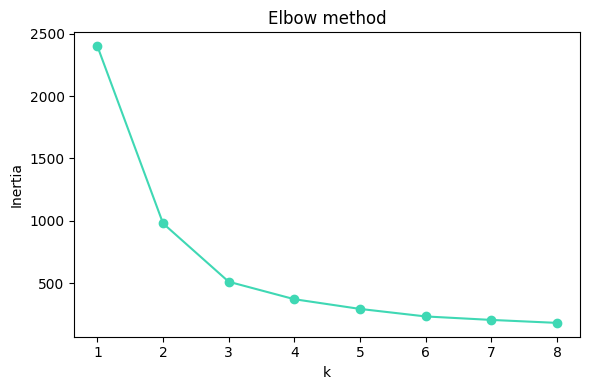

In [3]:
features = rfm[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
K = range(1, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K), inertias, marker='o', color='#3FD8B4')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow method')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=110)
plt.show()

## 3. Fit K-Means with k=4

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = rfm.groupby('cluster').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
).round(1)
cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary
cluster,,,,
0,324,121.3,2.9,2654.6
1,94,39.5,10.8,19678.4
2,144,68.6,6.7,10160.6
3,238,311.9,1.5,1010.2


## 4. Label segments from their RFM profile

In [5]:
def label_segment(row):
    if row['avg_recency'] < 60 and row['avg_frequency'] > 5:
        return 'Champions'
    elif row['avg_monetary'] > cluster_profile['avg_monetary'].median() and row['avg_recency'] > 100:
        return 'Big Spenders (Lapsed)'
    elif row['avg_frequency'] > 3:
        return 'Loyal Customers'
    else:
        return 'Low-Value / At Risk'

cluster_profile['segment'] = cluster_profile.apply(label_segment, axis=1)
segment_map = cluster_profile['segment'].to_dict()
rfm['segment'] = rfm['cluster'].map(segment_map)
cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,segment
cluster,,,,,
0,324,121.3,2.9,2654.6,Low-Value / At Risk
1,94,39.5,10.8,19678.4,Champions
2,144,68.6,6.7,10160.6,Loyal Customers
3,238,311.9,1.5,1010.2,Low-Value / At Risk


## 5. Visualize segments (PCA to 2D)

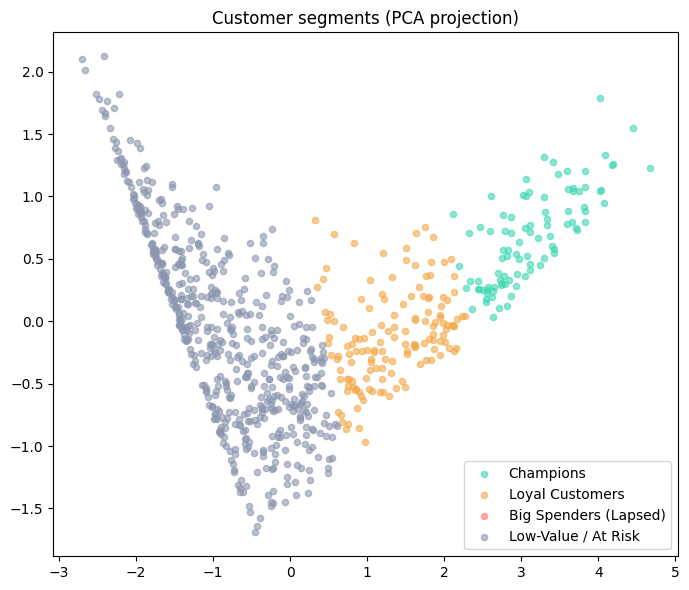

In [6]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
rfm['pc1'], rfm['pc2'] = coords[:,0], coords[:,1]

plt.figure(figsize=(7,6))
colors = {'Champions':'#3FD8B4', 'Loyal Customers':'#F4A94A', 'Big Spenders (Lapsed)':'#FF7A6E', 'Low-Value / At Risk':'#8B96AF'}
for seg, color in colors.items():
    subset = rfm[rfm['segment'] == seg]
    plt.scatter(subset['pc1'], subset['pc2'], label=seg, alpha=0.6, s=20, color=color)
plt.legend()
plt.title('Customer segments (PCA projection)')
plt.tight_layout()
plt.savefig('segments_pca.png', dpi=110)
plt.show()

## 6. Segment sizes and recommended actions

In [7]:
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

actions = {
    'Champions': 'Reward with early access / loyalty perks to keep them engaged.',
    'Loyal Customers': 'Upsell and cross-sell — they buy often, give them more reasons to.',
    'Big Spenders (Lapsed)': 'Win-back campaign — high value but going quiet, worth a direct outreach.',
    'Low-Value / At Risk': 'Low-cost nurture campaigns; not worth heavy investment yet.',
}
for seg, note in actions.items():
    print(f"- {seg}: {note}")

segment
Low-Value / At Risk    562
Loyal Customers        144
Champions               94
Name: count, dtype: int64
- Champions: Reward with early access / loyalty perks to keep them engaged.
- Loyal Customers: Upsell and cross-sell — they buy often, give them more reasons to.
- Big Spenders (Lapsed): Win-back campaign — high value but going quiet, worth a direct outreach.
- Low-Value / At Risk: Low-cost nurture campaigns; not worth heavy investment yet.


## Key findings
- RFM features (Recency, Frequency, Monetary) turn raw transaction logs into a compact
  behavioral signature per customer.
- The elbow method supports k=4 as a reasonable number of clusters — enough to be actionable,
  not so many that segments become impractical to act on.
- Each cluster is translated into a named segment with a specific marketing action, not left
  as an abstract cluster number — that's the difference between an analysis and a decision.